In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import re

In [2]:
def get_model_directories(base_dir):
    """
    Get all checkpoint directories with format rl_model_{stepsize}_steps from the given base directory.
    
    Args:
        base_dir (str): Parent directory to search for checkpoint folders
        
    Returns:
        list: List of absolute paths to rl_model directories, sorted by step size
    """
    model_dirs = []
    
    if not os.path.exists(base_dir):
        print(f"Warning: Directory {base_dir} does not exist")
        return model_dirs
    
    # Pattern to match rl_model_{stepsize}_steps directories
    pattern = re.compile(r'^rl_model_(\d+)_steps$')
    
    try:
        for item in os.listdir(base_dir):
            item_path = os.path.join(base_dir, item)
            if os.path.isdir(item_path):
                match = pattern.match(item)
                if match:
                    step_size = int(match.group(1))
                    model_dirs.append((step_size, item_path))
        
        # Sort by step size and return only the paths
        model_dirs.sort(key=lambda x: x[0])
        return [path for _, path in model_dirs]
        
    except OSError as e:
        print(f"Error reading directory {base_dir}: {e}")
        return []

In [3]:
def lookup_optimal_dir(experiment_dir):
    """
    Look for optimal model directories in an experiment directory.
    
    Args:
        experiment_dir (str): Path to experiment directory
        
    Returns:
        list: List of optimal model directories
    """
    optimal_dirs = []
    
    if not os.path.exists(experiment_dir):
        print(f"Warning: Experiment directory {experiment_dir} does not exist")
        return optimal_dirs
    
    # Get all task directories (numbered folders)
    task_dirs = []
    for item in os.listdir(experiment_dir):
        item_path = os.path.join(experiment_dir, item)
        if os.path.isdir(item_path) and item[0].isdigit():
            task_dirs.append((item, item_path))
    
    # Sort task directories by number
    task_dirs.sort(key=lambda x: int(x[0].split('_')[0]))
    
    for task_name, task_path in task_dirs:
        # Check if there's a decision file for this task
        decision_file = os.path.join(experiment_dir, f"{task_name}.md")
        
        if os.path.exists(decision_file):
            # Parse decision file to extract experiment number
            try:
                with open(decision_file, 'r') as f:
                    content = f.read()
                    
                # Look for "Decision: Experiment X" pattern
                decision_match = re.search(r'Decision:\s*Experiment\s*(\d+)', content, re.IGNORECASE)
                if decision_match:
                    experiment_num = int(decision_match.group(1))
                    optimal_sample_dir = os.path.join(task_path, f"sample_{experiment_num}")
                    
                    if os.path.exists(optimal_sample_dir):
                        model_dir = os.path.join(optimal_sample_dir, "model")
                        if os.path.exists(model_dir):
                            optimal_dirs.append(model_dir)
                        else:
                            print(f"Warning: Model directory not found in {optimal_sample_dir}")
                    else:
                        print(f"Warning: Sample directory {optimal_sample_dir} not found")
                else:
                    print(f"Warning: Could not parse decision from {decision_file}")
                    
            except Exception as e:
                print(f"Error reading decision file {decision_file}: {e}")
        
        if not any(task_name in path for path in optimal_dirs):
            # No decision file found or parsing failed, use highest numbered sample
            sample_dirs = []
            try:
                for item in os.listdir(task_path):
                    item_path = os.path.join(task_path, item)
                    if os.path.isdir(item_path) and item.startswith("sample_"):
                        try:
                            sample_num = int(item.split("_")[1])
                            sample_dirs.append((sample_num, item_path))
                        except (IndexError, ValueError):
                            continue
                
                if sample_dirs:
                    # Sort by sample number and get the highest one
                    sample_dirs.sort(key=lambda x: x[0])
                    highest_sample_num, highest_sample_dir = sample_dirs[-1]
                    
                    model_dir = os.path.join(highest_sample_dir, "model")
                    if os.path.exists(model_dir):
                        optimal_dirs.append(model_dir)
                    else:
                        print(f"Warning: Model directory not found in {highest_sample_dir}")
                else:
                    print(f"Warning: No sample directories found in {task_path}")
                    
            except OSError as e:
                print(f"Error listing directories in {task_path}: {e}")
    
    return optimal_dirs

In [4]:
# Pad all curves to max_length by extending with the final value
def pad_curve_to_length(curve, target_length):
    if len(curve) == 0:
        return [0] * target_length
    if len(curve) >= target_length:
        return curve[:target_length]
    # Extend with the final value
    final_value = curve[-1]
    padded_curve = curve + [final_value] * (target_length - len(curve))
    return padded_curve

In [5]:
def load_eval(model_path):
    # Load the evaluation results
    eval_results_path = os.path.join(model_path, "eval_results.pkl")
    if os.path.exists(eval_results_path):
        with open(eval_results_path, 'rb') as f:
            eval_results = pickle.load(f)

    return eval_results

In [6]:
def curriculum_evaluation(experiment_directories):
    total_success_summary = []
    partial_success_summary = []
    average_reward_summary = []
    std_reward_summary = []
    average_maximum_height_summary = []
    std_maximum_height_summary = []
    average_target_distance_summary = []
    std_target_distance_summary = []

    for experiment in experiment_directories:
        base_directories = lookup_optimal_dir(experiment)

        total_success_rate_curve = []
        partial_success_rate_curve = []
        average_reward_curve = []
        std_reward_curve = []
        average_maximum_height_curve = []
        std_maximum_height_curve = []
        average_target_distance_curve = []
        std_target_distance_curve = []

        for base_dir in base_directories:
            model_dirs = get_model_directories(base_dir)
            if not model_dirs:
                print(f"No model directories found in {base_dir}")
                break
            
            for model_path in model_dirs:
                eval_results = load_eval(model_path)
                
                total_success_rate_curve.append(eval_results['success_runs'] / eval_results['total_runs'] * 100 if eval_results['total_runs'] > 0 else 0)
                partial_success_rate_curve.append(eval_results['partial_success_runs'] / eval_results['total_runs'] * 100 if eval_results['total_runs'] > 0 else 0)
                average_reward_curve.append(eval_results['average_reward'])
                std_reward_curve.append(eval_results['std_reward'])
                average_maximum_height_curve.append(eval_results['average_maximum_height'])
                std_maximum_height_curve.append(eval_results['std_maximum_height'])
                average_target_distance_curve.append(eval_results['average_target_distance'])
                std_target_distance_curve.append(eval_results['std_target_distance'])

        total_success_summary.append(total_success_rate_curve)
        partial_success_summary.append(partial_success_rate_curve)
        average_reward_summary.append(average_reward_curve)
        std_reward_summary.append(std_reward_curve)
        average_maximum_height_summary.append(average_maximum_height_curve)
        std_maximum_height_summary.append(std_maximum_height_curve)
        average_target_distance_summary.append(average_target_distance_curve)
        std_target_distance_summary.append(std_target_distance_curve)

    # convert to numpy arrays for easier handling
    # Find the maximum length among all curves
    max_length = 0
    for curve_list in [total_success_summary, partial_success_summary, average_reward_summary, std_reward_summary, average_maximum_height_summary, std_maximum_height_summary, average_target_distance_summary, std_target_distance_summary]:
        for curve in curve_list:
            max_length = max(max_length, len(curve))
    
    print(f"Maximum curve length: {max_length}")
    
    # Pad and convert to numpy arrays
    total_success_summary_padded = []
    for curve in total_success_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        total_success_summary_padded.append(padded_curve)
    total_success_summary = np.array(total_success_summary_padded)
    
    partial_success_summary_padded = []
    for curve in partial_success_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        partial_success_summary_padded.append(padded_curve)
    partial_success_summary = np.array(partial_success_summary_padded)
    
    average_reward_summary_padded = []
    for curve in average_reward_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        average_reward_summary_padded.append(padded_curve)
    average_reward_summary = np.array(average_reward_summary_padded)
    
    std_reward_summary_padded = []
    for curve in std_reward_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        std_reward_summary_padded.append(padded_curve)
    std_reward_summary = np.array(std_reward_summary_padded)

    average_maximum_height_padded = []
    for curve in average_maximum_height_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        average_maximum_height_padded.append(padded_curve)
    average_maximum_height_summary = np.array(average_maximum_height_padded)

    std_maximum_height_padded = []
    for curve in std_maximum_height_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        std_maximum_height_padded.append(padded_curve)
    std_maximum_height_summary = np.array(std_maximum_height_padded)

    average_target_distance_padded = []
    for curve in average_target_distance_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        average_target_distance_padded.append(padded_curve)
    average_target_distance_summary = np.array(average_target_distance_padded)

    std_target_distance_padded = []
    for curve in std_target_distance_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        std_target_distance_padded.append(padded_curve)
    std_target_distance_summary = np.array(std_target_distance_padded)

    # return the result
    summarized_result = {
        "total_success": total_success_summary,
        "partial_success": partial_success_summary,
        "average_reward": average_reward_summary,
        "std_reward": std_reward_summary,
        "average_maximum_height": average_maximum_height_summary,
        "std_maximum_height": std_maximum_height_summary,
        "average_target_distance": average_target_distance_summary,
        "std_target_distance": std_target_distance_summary
    }
    return summarized_result

In [7]:
def scratch_evaluation(experiment_directories):

    total_success_summary = []
    partial_success_summary = []
    average_reward_summary = []
    std_reward_summary = []
    average_maximum_height_summary = []
    std_maximum_height_summary = []
    average_target_distance_summary = []
    std_target_distance_summary = []

    for experiment in experiment_directories:
        total_success_rate_curve = []
        partial_success_rate_curve = []
        average_reward_curve = []
        std_reward_curve = []
        average_maximum_height_curve = []
        std_maximum_height_curve = []
        average_target_distance_curve = []
        std_target_distance_curve = []

        model_dirs = get_model_directories(experiment)
        if not model_dirs:
            print(f"No model directories found in {experiment}")
            break
        
        for model_path in model_dirs:
            eval_results = load_eval(model_path)
        
            total_success_rate_curve.append(eval_results['success_runs'] / eval_results['total_runs'] * 100 if eval_results['total_runs'] > 0 else 0)
            partial_success_rate_curve.append(eval_results['partial_success_runs'] / eval_results['total_runs'] * 100 if eval_results['total_runs'] > 0 else 0)
            average_reward_curve.append(eval_results['average_reward'])
            std_reward_curve.append(eval_results['std_reward'])
            average_maximum_height_curve.append(eval_results['average_maximum_height'])
            std_maximum_height_curve.append(eval_results['std_maximum_height'])
            average_target_distance_curve.append(eval_results['average_target_distance'])
            std_target_distance_curve.append(eval_results['std_target_distance'])

        total_success_summary.append(total_success_rate_curve)
        partial_success_summary.append(partial_success_rate_curve)
        average_reward_summary.append(average_reward_curve)
        std_reward_summary.append(std_reward_curve)
        average_maximum_height_summary.append(average_maximum_height_curve)
        std_maximum_height_summary.append(std_maximum_height_curve)
        average_target_distance_summary.append(average_target_distance_curve)
        std_target_distance_summary.append(std_target_distance_curve)

    # convert to numpy arrays for easier handling
    # Find the maximum length among all curves
    max_length = 0
    for curve_list in [total_success_summary, partial_success_summary, average_reward_summary, std_reward_summary, average_maximum_height_summary, std_maximum_height_summary, average_target_distance_summary, std_target_distance_summary]:
        for curve in curve_list:
            max_length = max(max_length, len(curve))
    
    print(f"Maximum curve length: {max_length}")
    
    # Pad and convert to numpy arrays
    total_success_summary_padded = []
    for curve in total_success_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        total_success_summary_padded.append(padded_curve)
    total_success_summary = np.array(total_success_summary_padded)
    
    partial_success_summary_padded = []
    for curve in partial_success_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        partial_success_summary_padded.append(padded_curve)
    partial_success_summary = np.array(partial_success_summary_padded)
    
    average_reward_summary_padded = []
    for curve in average_reward_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        average_reward_summary_padded.append(padded_curve)
    average_reward_summary = np.array(average_reward_summary_padded)
    
    std_reward_summary_padded = []
    for curve in std_reward_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        std_reward_summary_padded.append(padded_curve)
    std_reward_summary = np.array(std_reward_summary_padded)

    average_maximum_height_padded = []
    for curve in average_maximum_height_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        average_maximum_height_padded.append(padded_curve)
    average_maximum_height_summary = np.array(average_maximum_height_padded)

    std_maximum_height_padded = []
    for curve in std_maximum_height_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        std_maximum_height_padded.append(padded_curve)
    std_maximum_height_summary = np.array(std_maximum_height_padded)

    average_target_distance_padded = []
    for curve in average_target_distance_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        average_target_distance_padded.append(padded_curve)
    average_target_distance_summary = np.array(average_target_distance_padded)

    std_target_distance_padded = []
    for curve in std_target_distance_summary:
        padded_curve = pad_curve_to_length(curve, max_length)
        std_target_distance_padded.append(padded_curve)
    std_target_distance_summary = np.array(std_target_distance_padded)

    # Return the result
    summarized_result = {
        "total_success": total_success_summary,
        "partial_success": partial_success_summary,
        "average_reward": average_reward_summary,
        "std_reward": std_reward_summary,
        "average_maximum_height": average_maximum_height_summary,
        "std_maximum_height": std_maximum_height_summary,
        "average_target_distance": average_target_distance_summary,
        "std_target_distance": std_target_distance_summary
    }
    return summarized_result


In [8]:
curriculum_directories = [
    # "logs/go2seesaw/08-15_14-38",
    # "logs/go2seesaw/08-16_08-41",
    # "logs/go2seesaw/08-17_10-44",
    "logs/go2seesaw/08-17_10-44",
    "logs/go2seesaw/08-18_09-25",
    "logs/go2seesaw/08-19_02-44",
    # "logs/go2seesaw/09-02_21-09",
    # "logs/go2seesaw/09-03_09-20",
    # "logs/go2seesaw/09-03_17-49",
]

no_refine_directories = [
    "logs/go2seesaw/09-01_03-39_no_refine",
    # "logs/go2seesaw/09-01_21-45_no_refine",
    "logs/go2seesaw/09-02_17-02_no_refine",
    "logs/go2seesaw/09-03_11-53_no_refine",
    # "logs/go2seesaw/09-04_04-43_no_refine",
]

scratch_directories = [
    "checkpoints/go2seesaw_08-17_10-44_scratch",
    "checkpoints/go2seesaw_08-18_09-25_scratch",
    "checkpoints/go2seesaw_08-19_02-44_scratch",
]

example_directories = [
    "checkpoints/go2seesaw_example_reward_0",
    "checkpoints/go2seesaw_example_reward_1",
    "checkpoints/go2seesaw_example_reward_2",
    "checkpoints/go2seesaw_example_reward_3",
    "checkpoints/go2seesaw_example_reward_4"
]

mqe_directories = [
    "checkpoints/go2seesaw_mqe_reward_0",
    "checkpoints/go2seesaw_mqe_reward_1",
    "checkpoints/go2seesaw_mqe_reward_2",
    "checkpoints/go2seesaw_mqe_reward_3",
    "checkpoints/go2seesaw_mqe_reward_4",
]

curriculum_results = curriculum_evaluation(curriculum_directories)
scratch_results = scratch_evaluation(scratch_directories)
no_refine_results = curriculum_evaluation(no_refine_directories)
example_results = scratch_evaluation(example_directories)
mqe_results = scratch_evaluation(mqe_directories)

Maximum curve length: 32
Maximum curve length: 32
Maximum curve length: 32
Maximum curve length: 32
Maximum curve length: 32


In [9]:
# Print out the results for verification
for idx in range(curriculum_results['total_success'].shape[0]):
    print(f"Curriculum run {idx}: success={curriculum_results['total_success'][idx, -1]:.2f}%, partial_success={curriculum_results['partial_success'][idx, -1]:.2f}%, avg_reward={curriculum_results['average_reward'][idx, -1]:.3f}, std_reward={curriculum_results['std_reward'][idx, -1]:.3f}, avg_max_height={curriculum_results['average_maximum_height'][idx, -1]:.3f}, std_max_height={curriculum_results['std_maximum_height'][idx, -1]:.3f}, avg_target_distance={curriculum_results['average_target_distance'][idx, -1]:.3f}, std_target_distance={curriculum_results['std_target_distance'][idx, -1]:.3f}")

for idx in range(scratch_results['total_success'].shape[0]):
    print(f"Scratch run {idx}: success={scratch_results['total_success'][idx, -1]:.2f}%, partial_success={scratch_results['partial_success'][idx, -1]:.2f}%, avg_reward={scratch_results['average_reward'][idx, -1]:.3f}, std_reward={scratch_results['std_reward'][idx, -1]:.3f}, avg_max_height={scratch_results['average_maximum_height'][idx, -1]:.3f}, std_max_height={scratch_results['std_maximum_height'][idx, -1]:.3f}, avg_target_distance={scratch_results['average_target_distance'][idx, -1]:.3f}, std_target_distance={scratch_results['std_target_distance'][idx, -1]:.3f}")

for idx in range(no_refine_results['total_success'].shape[0]):
    print(f"No refine run {idx}: success={no_refine_results['total_success'][idx, -1]:.2f}%, partial_success={no_refine_results['partial_success'][idx, -1]:.2f}%, avg_reward={no_refine_results['average_reward'][idx, -1]:.3f}, std_reward={no_refine_results['std_reward'][idx, -1]:.3f}, avg_max_height={no_refine_results['average_maximum_height'][idx, -1]:.3f}, std_max_height={no_refine_results['std_maximum_height'][idx, -1]:.3f}, avg_target_distance={no_refine_results['average_target_distance'][idx, -1]:.3f}, std_target_distance={no_refine_results['std_target_distance'][idx, -1]:.3f}")

for idx in range(example_results['total_success'].shape[0]):
    print(f"Example run {idx}: success={example_results['total_success'][idx, -1]:.2f}%, partial_success={example_results['partial_success'][idx, -1]:.2f}%, avg_reward={example_results['average_reward'][idx, -1]:.3f}, std_reward={example_results['std_reward'][idx, -1]:.3f}, avg_max_height={example_results['average_maximum_height'][idx, -1]:.3f}, std_max_height={example_results['std_maximum_height'][idx, -1]:.3f}, avg_target_distance={example_results['average_target_distance'][idx, -1]:.3f}, std_target_distance={example_results['std_target_distance'][idx, -1]:.3f}")

for idx in range(mqe_results['total_success'].shape[0]):
    print(f"MQE run {idx}: success={mqe_results['total_success'][idx, -1]:.2f}%, partial_success={mqe_results['partial_success'][idx, -1]:.2f}%, avg_reward={mqe_results['average_reward'][idx, -1]:.3f}, std_reward={mqe_results['std_reward'][idx, -1]:.3f}, avg_max_height={mqe_results['average_maximum_height'][idx, -1]:.3f}, std_max_height={mqe_results['std_maximum_height'][idx, -1]:.3f}, avg_target_distance={mqe_results['average_target_distance'][idx, -1]:.3f}, std_target_distance={mqe_results['std_target_distance'][idx, -1]:.3f}")

Curriculum run 0: success=45.54%, partial_success=99.01%, avg_reward=1482.130, std_reward=636.739, avg_max_height=1.233, std_max_height=0.136, avg_target_distance=0.634, std_target_distance=0.654
Curriculum run 1: success=35.00%, partial_success=95.00%, avg_reward=648.440, std_reward=402.464, avg_max_height=1.147, std_max_height=0.229, avg_target_distance=1.041, std_target_distance=1.077
Curriculum run 2: success=17.00%, partial_success=87.00%, avg_reward=146.190, std_reward=71.270, avg_max_height=1.082, std_max_height=0.276, avg_target_distance=1.491, std_target_distance=1.620
Scratch run 0: success=26.00%, partial_success=66.00%, avg_reward=120.032, std_reward=72.721, avg_max_height=0.949, std_max_height=0.398, avg_target_distance=2.201, std_target_distance=2.150
Scratch run 1: success=32.00%, partial_success=99.00%, avg_reward=187.460, std_reward=50.589, avg_max_height=1.219, std_max_height=0.147, avg_target_distance=0.655, std_target_distance=0.707
Scratch run 2: success=16.00%, pa

In [10]:
# Plot the success rates
plt.rcParams["font.family"] = "P052" 
plt.rcParams['pdf.fonttype'] = 42  # Use TrueType
plt.rcParams['ps.fonttype'] = 42
curriculum_color = "#1f77b4"  # Blue
scratch_color = "#ff7f0e"     # Orange
no_refine_color = "#2ca02c"   # Green
example_color = "#d62728"     # Red
mqe_color = "#9467bd"         # Purple

x = np.arange(curriculum_results['total_success'].shape[1]) * 2500000

In [11]:
# Plot the average success rate with shaded std
def plot_with_std(ax, x, mean_curve, std_curve, label, color):    
    ax.plot(x, mean_curve, label=label, color=color, linewidth=3)
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.1)

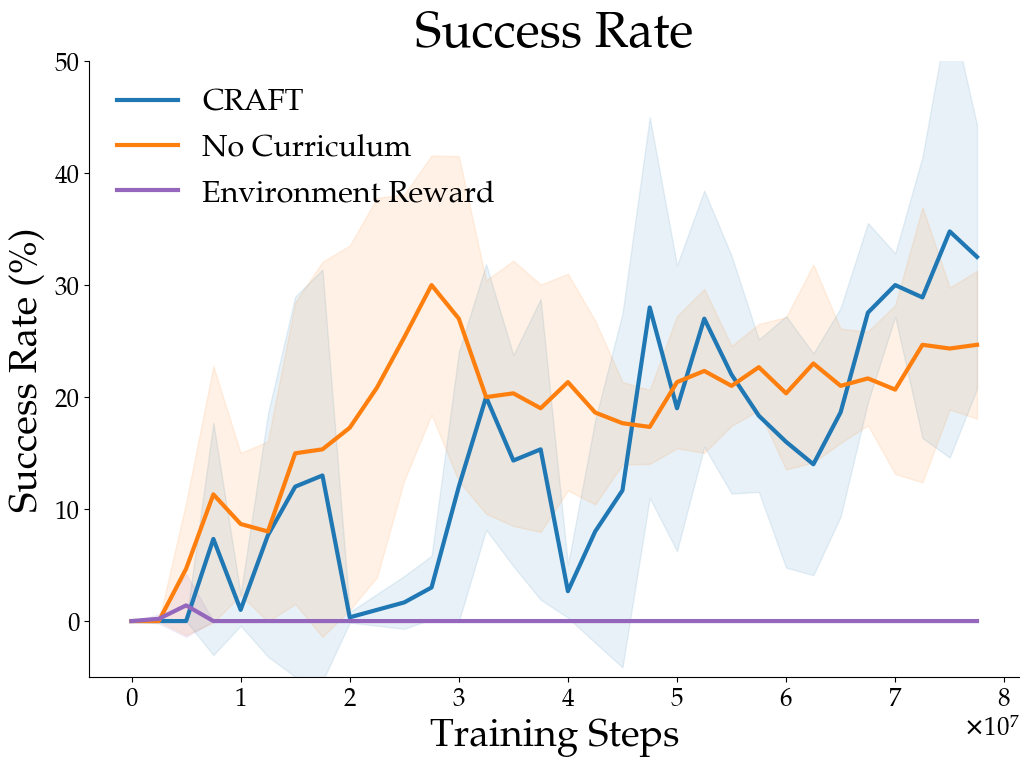

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 8))
# Total Success Rate
mean_curriculum_success = np.mean(curriculum_results['total_success'], axis=0) 
std_curriculum_success = np.std(curriculum_results['total_success'], axis=0)
mean_scratch_success = np.mean(scratch_results['total_success'], axis=0)
std_scratch_success = np.std(scratch_results['total_success'], axis=0)
mean_no_refine_success = np.mean(no_refine_results['total_success'], axis=0)
std_no_refine_success = np.std(no_refine_results['total_success'], axis=0)
mean_example_success = np.mean(example_results['total_success'], axis=0)
std_example_success = np.std(example_results['total_success'], axis=0)
mean_mqe_success = np.mean(mqe_results['total_success'], axis=0)
std_mqe_success = np.std(mqe_results['total_success'], axis=0)

plot_with_std(plt.gca(), x, mean_curriculum_success, std_curriculum_success, "CRAFT", curriculum_color)
plot_with_std(plt.gca(), x, mean_scratch_success, std_scratch_success, "No Curriculum", scratch_color)
plot_with_std(plt.gca(), x, mean_no_refine_success, std_no_refine_success, "No Refine", no_refine_color)
# plot_with_std(plt.gca(), x, mean_example_success, std_example_success, "Example Reward", example_color)
plot_with_std(plt.gca(), x, mean_mqe_success, std_mqe_success, "Environment Reward", mqe_color)
plt.title("Success Rate", fontsize=36)
plt.xlabel("Training Steps", fontsize=28)
plt.ylabel("Success Rate (%)", fontsize=28)
plt.tick_params(axis='both', which='both', labelsize=18)
plt.ylim(-5, 50)

plt.legend(frameon=False, loc="upper left", fontsize=22)
plt.grid(False)
# Remove edge lines in right and upper side
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.gca().xaxis.offsetText.set_fontsize(18)
plt.savefig("figure/seesaw_total_success_rate.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# print the final average success rates
print(f"Final Curriculum Success Rate: {mean_curriculum_success[-1]:.2f}% ± {std_curriculum_success[-1]:.2f}%")
print(f"Final Scratch Success Rate: {mean_scratch_success[-1]:.2f}% ± {std_scratch_success[-1]:.2f}%")
print(f"Final No Refine Success Rate: {mean_no_refine_success[-1]:.2f}% ± {std_no_refine_success[-1]:.2f}%")
print(f"Final Example Reward Success Rate: {mean_example_success[-1]:.2f}% ± {std_example_success[-1]:.2f}%")
print(f"Final MQE Reward Success Rate: {mean_mqe_success[-1]:.2f}% ± {std_mqe_success[-1]:.2f}%")

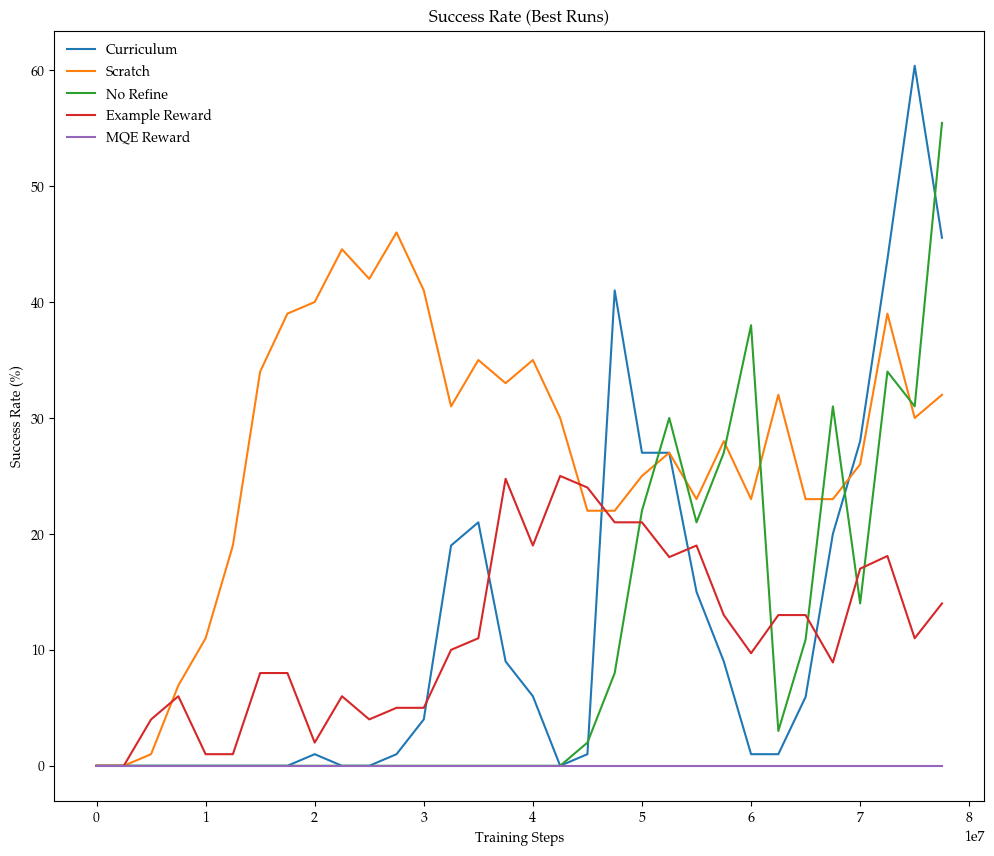

In [63]:
# Only plot the run with the highest final success rate for each method
best_curriculum_idx = np.argmax(curriculum_results['total_success'][:, -1])
best_scratch_idx = np.argmax(scratch_results['total_success'][:, -1])
best_no_refine_idx = np.argmax(no_refine_results['total_success'][:, -1])
best_example_idx = np.argmax(example_results['total_success'][:, -1])
best_mqe_idx = np.argmax(mqe_results['total_success'][:, -1])

plt.figure(figsize=(12, 10))
# Total Success Rate for best runs
plt.plot(x, curriculum_results['total_success'][best_curriculum_idx], label="Curriculum", color=curriculum_color)
plt.plot(x, scratch_results['total_success'][best_scratch_idx], label="Scratch", color=scratch_color)
plt.plot(x, no_refine_results['total_success'][best_no_refine_idx], label="No Refine", color=no_refine_color)
plt.plot(x, example_results['total_success'][best_example_idx], label="Example Reward", color=example_color)
plt.plot(x, mqe_results['total_success'][best_mqe_idx], label="MQE Reward", color=mqe_color)
plt.title("Success Rate (Best Runs)") 
plt.xlabel("Training Steps")
plt.ylabel("Success Rate (%)")

plt.legend(frameon=False, loc="upper left")
plt.grid(False)
plt.show()

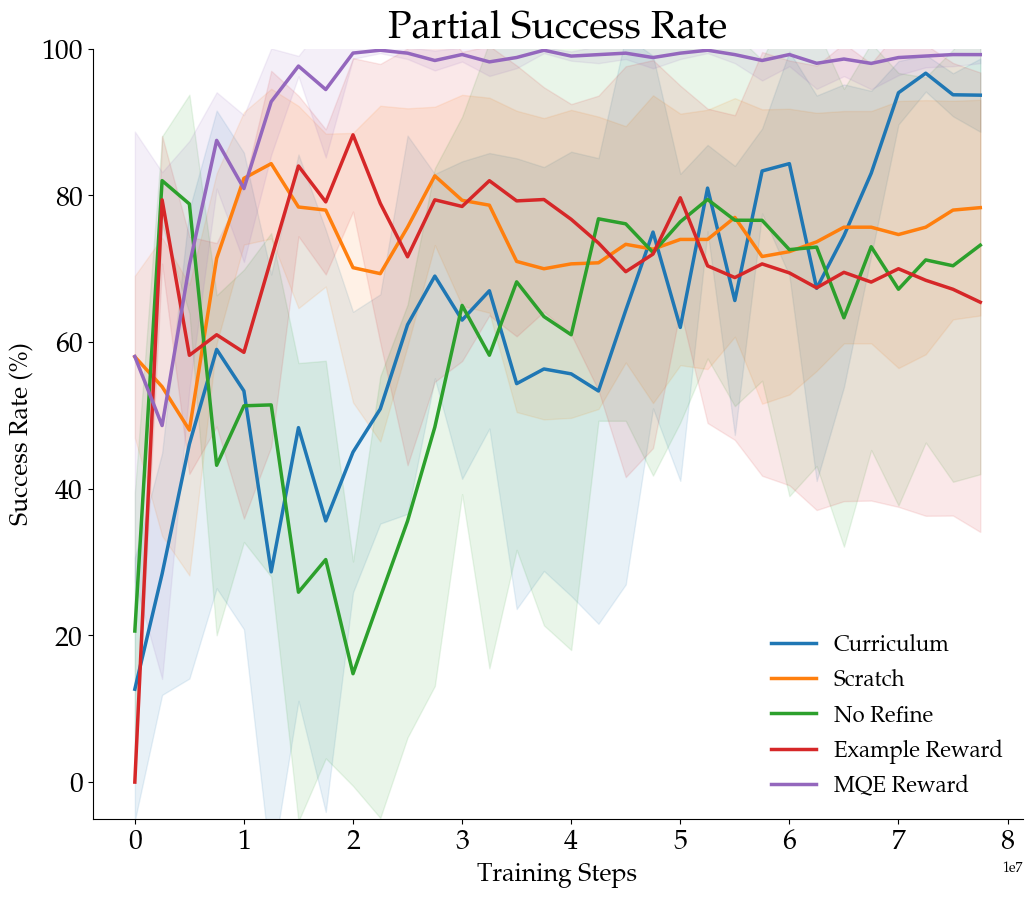

In [47]:
# Plot the partial success rate, which is partial success rate 
plt.figure(figsize=(12, 10))
# Partial Success Rate
mean_curriculum_partial_success = np.mean(curriculum_results['partial_success'], axis=0)
std_curriculum_partial_success = np.std(curriculum_results['partial_success'], axis=0)
mean_scratch_partial_success = np.mean(scratch_results['partial_success'], axis=0)
std_scratch_partial_success = np.std(scratch_results['partial_success'], axis=0)
mean_no_refine_partial_success = np.mean(no_refine_results['partial_success'], axis=0) 
std_no_refine_partial_success = np.std(no_refine_results['partial_success'], axis=0)
mean_example_partial_success = np.mean(example_results['partial_success'], axis=0)
std_example_partial_success = np.std(example_results['partial_success'], axis=0)
mean_mqe_partial_success = np.mean(mqe_results['partial_success'], axis=0) 
std_mqe_partial_success = np.std(mqe_results['partial_success'], axis=0)

plot_with_std(plt.gca(), x, mean_curriculum_partial_success, std_curriculum_partial_success, "Curriculum", curriculum_color)
plot_with_std(plt.gca(), x, mean_scratch_partial_success, std_scratch_partial_success, "Scratch", scratch_color)
plot_with_std(plt.gca(), x, mean_no_refine_partial_success, std_no_refine_partial_success, "No Refine", no_refine_color)
plot_with_std(plt.gca(), x, mean_example_partial_success, std_example_partial_success, "Example Reward", example_color)
plot_with_std(plt.gca(), x, mean_mqe_partial_success, std_mqe_partial_success, "MQE Reward", mqe_color)
plt.title("Partial Success Rate", fontsize=28)
plt.xlabel("Training Steps", fontsize=18)   
plt.ylabel("Success Rate (%)", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.ylim(-5, 100)

plt.legend(frameon=False, loc="lower right", fontsize=16)
plt.grid(False)
# Remove edge lines in right and upper side
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

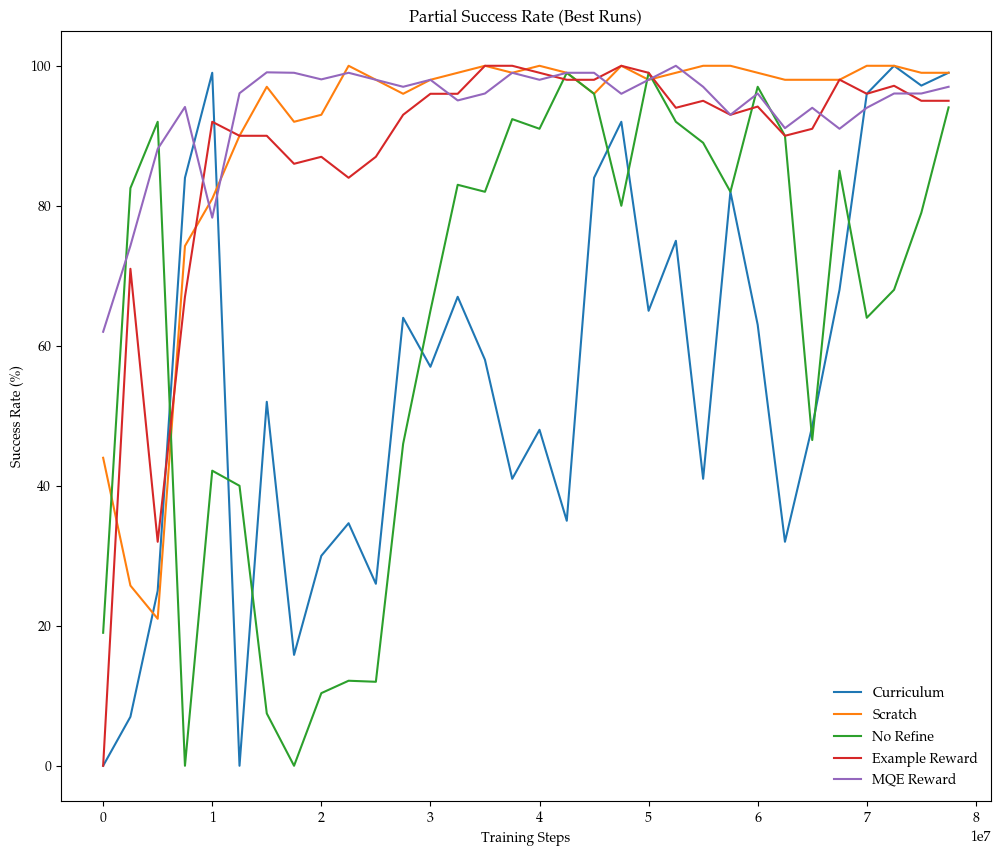

In [48]:
# Best runs for partial success rate
plt.figure(figsize=(12, 10))
# Partial Success Rate for best runs
plt.plot(x, curriculum_results['partial_success'][best_curriculum_idx], label="Curriculum", color=curriculum_color)
plt.plot(x, scratch_results['partial_success'][best_scratch_idx], label="Scratch", color=scratch_color)
plt.plot(x, no_refine_results['partial_success'][best_no_refine_idx], label="No Refine", color=no_refine_color)
plt.plot(x, example_results['partial_success'][best_example_idx], label="Example Reward", color=example_color)
plt.plot(x, mqe_results['partial_success'][best_mqe_idx], label="MQE Reward", color=mqe_color)
plt.title("Partial Success Rate (Best Runs)")
plt.xlabel("Training Steps")
plt.ylabel("Success Rate (%)")
plt.ylim(-5, 105)
plt.legend(frameon=False, loc="lower right")
plt.grid(False)
plt.show()

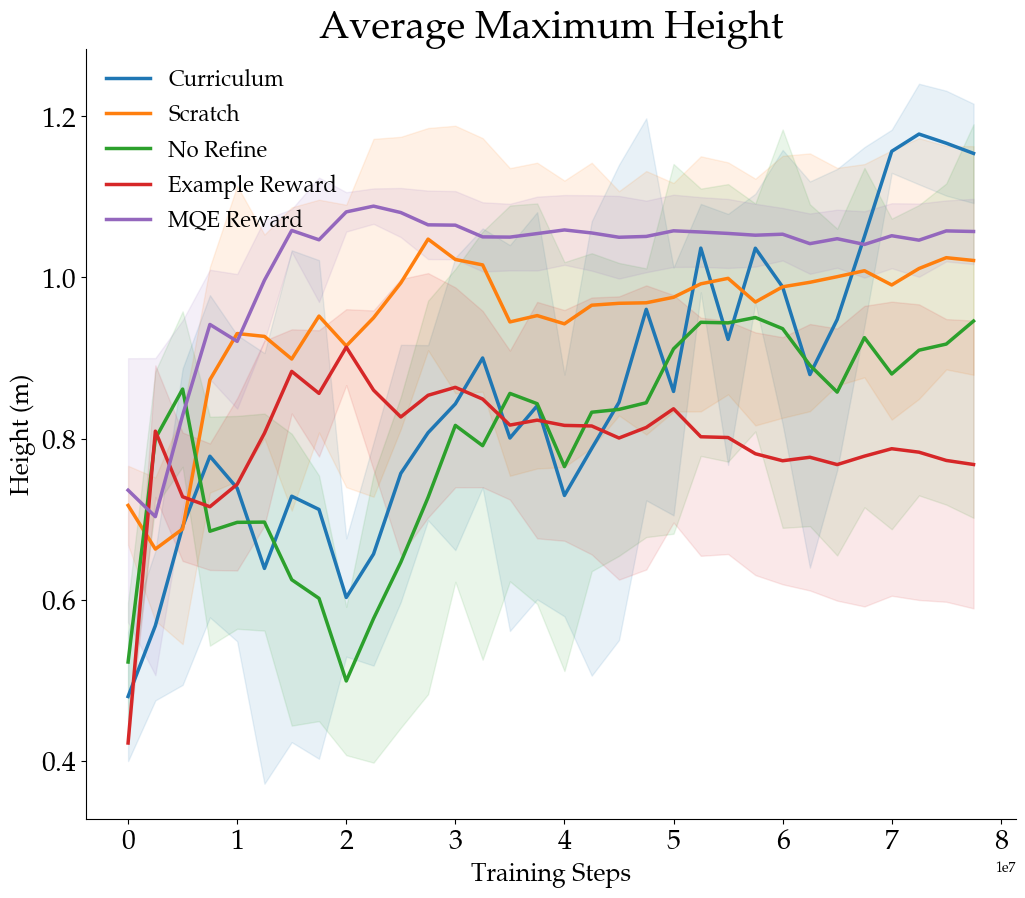

In [49]:
# Plot the distance to the goal
plt.figure(figsize=(12, 10))
# Average maximum height
mean_curriculum_min_dist = np.mean(curriculum_results['average_maximum_height'], axis=0)
std_curriculum_min_dist = np.std(curriculum_results['average_maximum_height'], axis=0)
mean_scratch_min_dist = np.mean(scratch_results['average_maximum_height'], axis=0)
std_scratch_min_dist = np.std(scratch_results['average_maximum_height'], axis=0)
mean_no_refine_min_dist = np.mean(no_refine_results['average_maximum_height'], axis=0)
std_no_refine_min_dist = np.std(no_refine_results['average_maximum_height'], axis=0)
mean_example_min_dist = np.mean(example_results['average_maximum_height'], axis=0)
std_example_min_dist = np.std(example_results['average_maximum_height'], axis=0)
mean_mqe_min_dist = np.mean(mqe_results['average_maximum_height'], axis=0)
std_mqe_min_dist = np.std(mqe_results['average_maximum_height'], axis=0)

plot_with_std(plt.gca(), x, mean_curriculum_min_dist, std_curriculum_min_dist, "Curriculum", curriculum_color)
plot_with_std(plt.gca(), x, mean_scratch_min_dist, std_scratch_min_dist, "Scratch", scratch_color)
plot_with_std(plt.gca(), x, mean_no_refine_min_dist, std_no_refine_min_dist, "No Refine", no_refine_color)
plot_with_std(plt.gca(), x, mean_example_min_dist, std_example_min_dist, "Example Reward", example_color)
plot_with_std(plt.gca(), x, mean_mqe_min_dist, std_mqe_min_dist, "MQE Reward", mqe_color)
plt.title("Average Maximum Height", fontsize=28)
plt.xlabel("Training Steps", fontsize=18)
plt.ylabel("Height (m)", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.legend(frameon=False, loc="upper left", fontsize=16)
plt.grid(False)
# Remove edge lines in right and upper side
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

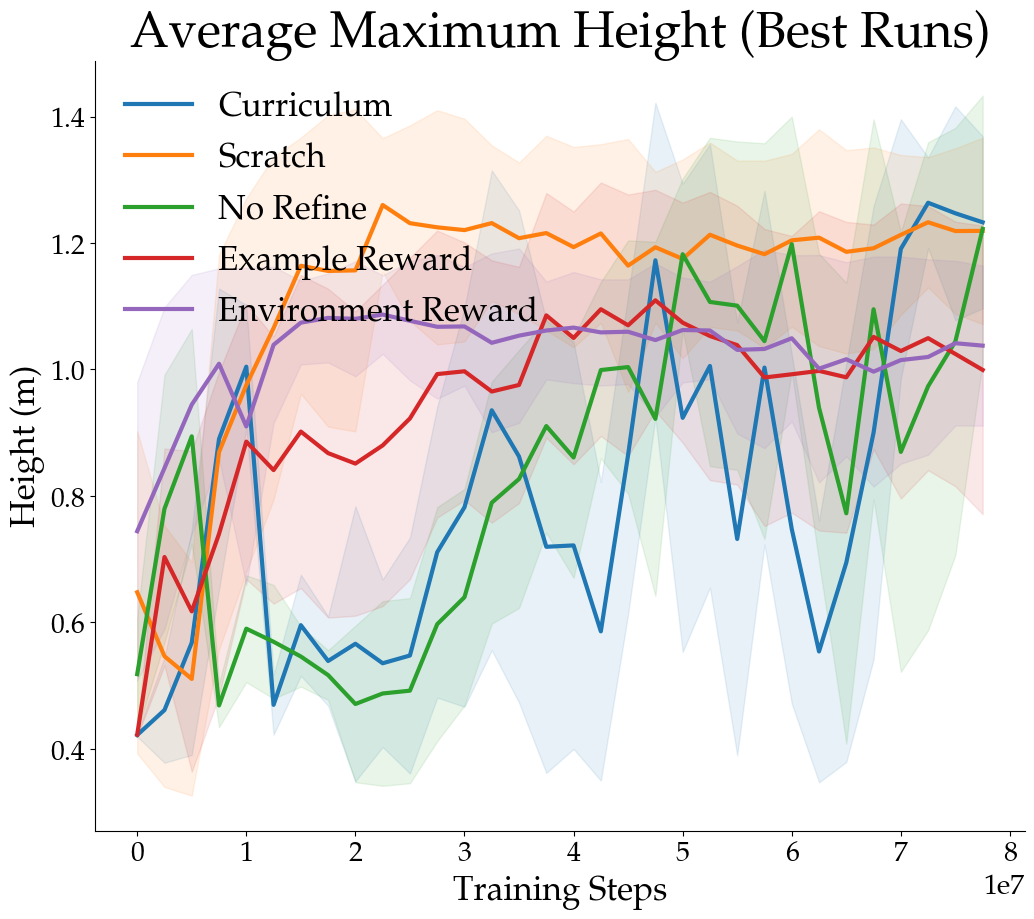

In [65]:
# Average maximum height for best runs
plt.figure(figsize=(12, 10))
# Average maximum height for best runs and std shaded
plot_with_std(plt.gca(), x, curriculum_results['average_maximum_height'][best_curriculum_idx], curriculum_results['std_maximum_height'][best_curriculum_idx], "Curriculum", curriculum_color)
plot_with_std(plt.gca(), x, scratch_results['average_maximum_height'][best_scratch_idx], scratch_results['std_maximum_height'][best_scratch_idx], "Scratch", scratch_color)
plot_with_std(plt.gca(), x, no_refine_results['average_maximum_height'][best_no_refine_idx], no_refine_results['std_maximum_height'][best_no_refine_idx], "No Refine", no_refine_color)
plot_with_std(plt.gca(), x, example_results['average_maximum_height'][best_example_idx], example_results['std_maximum_height'][best_example_idx], "Example Reward", example_color)
plot_with_std(plt.gca(), x, mqe_results['average_maximum_height'][best_mqe_idx], mqe_results['std_maximum_height'][best_mqe_idx], "Environment Reward", mqe_color)
plt.title("Average Maximum Height (Best Runs)", fontsize=36)
plt.xlabel("Training Steps", fontsize=24)
plt.ylabel("Height (m)", fontsize=24)
plt.tick_params(axis='both', which='both', labelsize=20)
plt.legend(frameon=False, loc="upper left", fontsize=24)
plt.grid(False)
# Remove edge lines in right and upper side
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().xaxis.offsetText.set_fontsize(20)
plt.savefig("figure/seesaw_maximum_height.pdf", bbox_inches='tight', dpi=300)

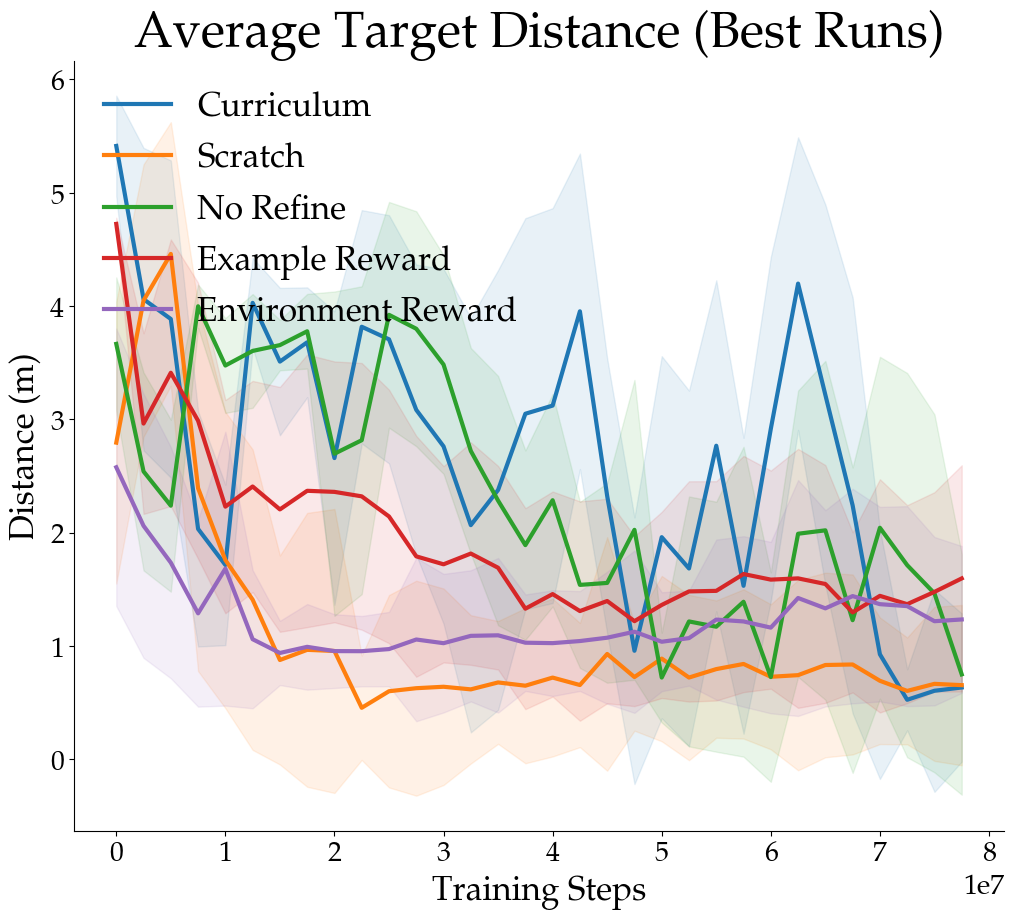

In [66]:
# Average target distance of best runs
plt.figure(figsize=(12, 10))
# Average target distance for best runs and std shaded
plot_with_std(plt.gca(), x, curriculum_results['average_target_distance'][best_curriculum_idx], curriculum_results['std_target_distance'][best_curriculum_idx], "Curriculum", curriculum_color)
plot_with_std(plt.gca(), x, scratch_results['average_target_distance'][best_scratch_idx], scratch_results['std_target_distance'][best_scratch_idx], "Scratch", scratch_color)
plot_with_std(plt.gca(), x, no_refine_results['average_target_distance'][best_no_refine_idx], no_refine_results['std_target_distance'][best_no_refine_idx], "No Refine", no_refine_color)
plot_with_std(plt.gca(), x, example_results['average_target_distance'][best_example_idx], example_results['std_target_distance'][best_example_idx], "Example Reward", example_color)
plot_with_std(plt.gca(), x, mqe_results['average_target_distance'][best_mqe_idx], mqe_results['std_target_distance'][best_mqe_idx], "Environment Reward", mqe_color)
plt.title("Average Target Distance (Best Runs)", fontsize=36)
plt.xlabel("Training Steps", fontsize=24)
plt.ylabel("Distance (m)", fontsize=24)
plt.tick_params(axis='both', which='both', labelsize=20)
plt.legend(frameon=False, loc="upper left", fontsize=24)
plt.grid(False)
# Remove edge lines in right and upper side
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().xaxis.offsetText.set_fontsize(20)
plt.savefig("figure/seesaw_target_distance.pdf", bbox_inches='tight', dpi=300)
plt.show()